In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import KFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix, roc_auc_score)
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [2]:
soy_raw = pd.read_csv('soy_raw.csv')
sm = pd.read_csv('sm.csv')
vod = pd.read_csv('vod.csv')

In [3]:
# Process the daily soil moisture and VOD data into a 4-month mean, 95th percentile, 5th percentile and standard deviation.

sm_data = pd.DataFrame({
    'sm_mean': sm.mean(axis=1),
    'sm_q5': sm.quantile(0.05, axis=1),
    'sm_q95': sm.quantile(0.95, axis=1),
    'sm_std': sm.std(axis=1)
})

vod_data = pd.DataFrame({
    'vod_mean': vod.mean(axis=1),
    'vod_q5': vod.quantile(0.05,axis=1),
    'vod_q95': vod.quantile(0.95,axis=1),
    'vod_std': vod.std(axis=1)
})

sm_data.head()

,sm_mean,sm_q5,sm_q95,sm_std
0,0.160216,0.091869,0.238131,0.044583
1,0.197299,0.138234,0.236725,0.032614
2,0.172573,0.073943,0.233433,0.045325
3,0.220197,0.152329,0.265495,0.035747
4,0.179592,0.063475,0.265588,0.055550


In [4]:
# Calculate yield anomaly per county per datapoint for the logistic regressiojn

train_years_mask = soy_raw['year'] < 2018
county_train_mean = soy_raw.loc[train_years_mask].groupby('county')['yield'].mean()
county_train_mean.name = 'county_mean_yield'

soy_raw = soy_raw.merge(county_train_mean, on='county', how='left')
soy_raw.insert(0,'yield_anomaly', soy_raw['yield']-soy_raw['county_mean_yield'])
soy_raw = soy_raw.drop(labels=['county_mean_yield','county'],axis=1)

soy_raw.head()

,yield_anomaly,year,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul
0,-0.673008,2015,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132
1,-0.737090,2015,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022
2,0.255987,2015,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778
3,-0.489603,2015,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999
4,-0.462537,2015,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548


In [5]:
# Combine all values into one final dataframe

soy_data = pd.concat([soy_raw, sm_data, vod_data],axis=1)
soy_data.head()

,yield_anomaly,year,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul,sm_mean,sm_q5,sm_q95,sm_std,vod_mean,vod_q5,vod_q95,vod_std
0,-0.673008,2015,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132,0.160216,0.091869,0.238131,0.044583,0.393141,0.316100,0.494518,0.054919
1,-0.737090,2015,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022,0.197299,0.138234,0.236725,0.032614,0.279009,0.225902,0.321308,0.032779
2,0.255987,2015,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778,0.172573,0.073943,0.233433,0.045325,0.227040,0.167861,0.288062,0.038181
3,-0.489603,2015,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999,0.220197,0.152329,0.265495,0.035747,0.317403,0.262077,0.391281,0.038965
4,-0.462537,2015,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548,0.179592,0.063475,0.265588,0.055550,0.206323,0.136790,0.282111,0.047684


<Axes: >

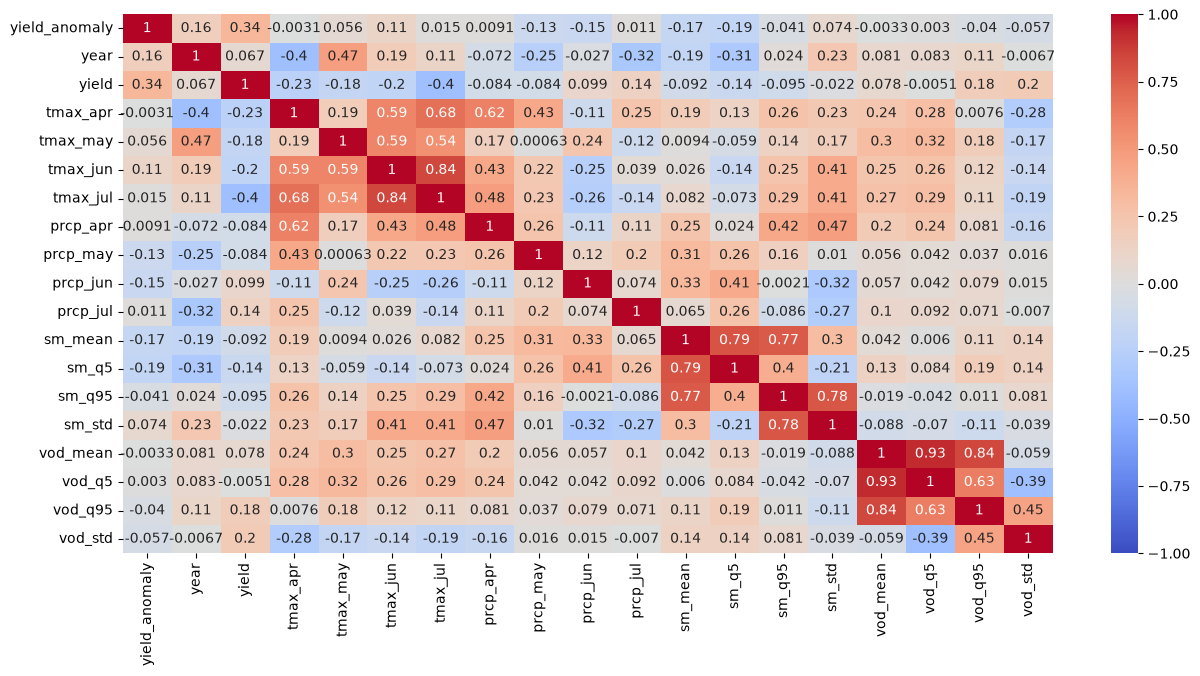

In [6]:
# Create a correlation matrix to determine features.

fig,axes = plt.subplots(1,1,figsize=(15,7))
soy_corr_mat = soy_data.corr(numeric_only=True)
sb.heatmap(soy_corr_mat, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes)

<Axes: >

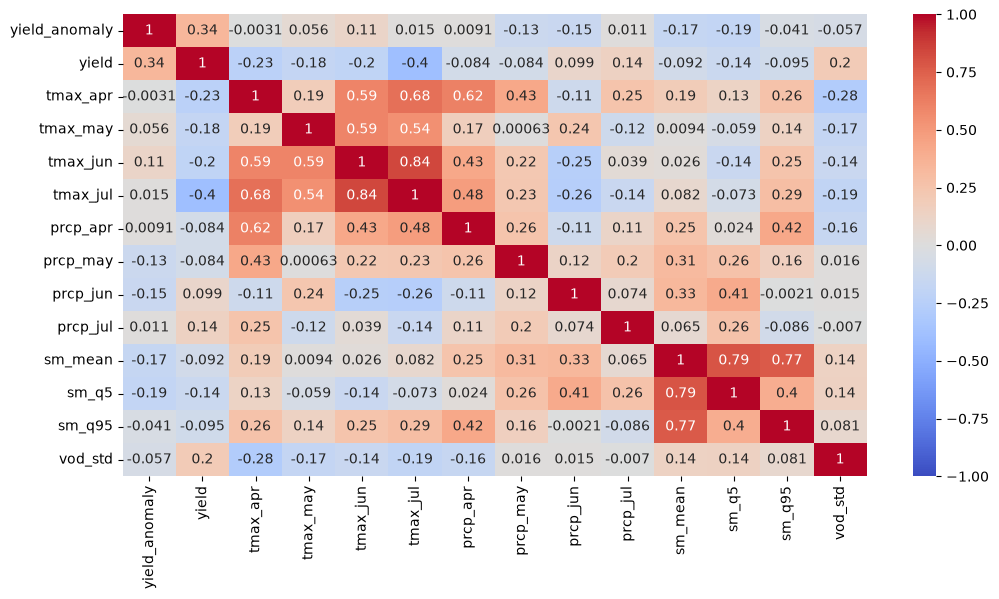

In [7]:
# Create a second correlation matrix with only the features and the label for legibility.


fig,axes2 = plt.subplots(1,1,figsize=(12,6))
soy_new = soy_data.drop(columns=["sm_std","vod_mean","vod_q5","vod_q95"])
soy_corr_mat_3 = soy_new.drop(columns=["year"]).corr(numeric_only=True)
sb.heatmap(soy_corr_mat_3, annot=True, vmin=-1, vmax=1, cmap='coolwarm', ax=axes2)


In [8]:
# Create training sets and testing sets

features = soy_new.columns.drop(['yield','year','yield_anomaly'])

X_train = soy_new.loc[soy_new['year']<2018, features].to_numpy()
y_train = soy_new.loc[soy_new['year']<2018, 'yield'].to_numpy()

X_test = soy_new.loc[soy_new['year']==2018, features].to_numpy()
y_test = soy_new.loc[soy_new['year']==2018, 'yield'].to_numpy()

print('features:', list(features))
print('train shape:', X_train.shape, 'test shape:', X_test.shape)

features: ['tmax_apr', 'tmax_may', 'tmax_jun', 'tmax_jul', 'prcp_apr', 'prcp_may', 'prcp_jun', 'prcp_jul', 'sm_mean', 'sm_q5', 'sm_q95', 'vod_std']
train shape: (1545, 12) test shape: (515, 12)


In [9]:
# Normalise features

scaler = StandardScaler()

scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

In [10]:
# Train the Ridge parameter

alphas = np.logspace(-2, 5, 20)

model = RidgeCV(alphas = alphas, cv = 3, scoring = 'neg_root_mean_squared_error')

model.fit(X_train_norm,y_train)

y_pred = model.predict(X_test_norm)
print(root_mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

print(model.get_params())

print("best alpha:", model.alpha_)
print("CV RMSE at best alpha:", -model.best_score_)


2.128427306019578
0.08609273579060184
{'alpha_per_target': False, 'alphas': array([1.00000000e-02, 2.33572147e-02, 5.45559478e-02, 1.27427499e-01,
       2.97635144e-01, 6.95192796e-01, 1.62377674e+00, 3.79269019e+00,
       8.85866790e+00, 2.06913808e+01, 4.83293024e+01, 1.12883789e+02,
       2.63665090e+02, 6.15848211e+02, 1.43844989e+03, 3.35981829e+03,
       7.84759970e+03, 1.83298071e+04, 4.28133240e+04, 1.00000000e+05]), 'cv': 3, 'fit_intercept': True, 'gcv_mode': None, 'scoring': 'neg_root_mean_squared_error', 'store_cv_results': False}
best alpha: 263.6650898730355
CV RMSE at best alpha: 1.9960317417188864


In [11]:
soy_new.head()

,yield_anomaly,year,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul,sm_mean,sm_q5,sm_q95,vod_std
0,-0.673008,2015,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132,0.160216,0.091869,0.238131,0.054919
1,-0.737090,2015,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022,0.197299,0.138234,0.236725,0.032779
2,0.255987,2015,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778,0.172573,0.073943,0.233433,0.038181
3,-0.489603,2015,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999,0.220197,0.152329,0.265495,0.038965
4,-0.462537,2015,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548,0.179592,0.063475,0.265588,0.047684


In [12]:
soy_new.insert(0, 'year_goodness', (soy_new['yield_anomaly'] > 0).astype(int))
soy_new.head()

,year_goodness,yield_anomaly,year,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul,sm_mean,sm_q5,sm_q95,vod_std
0,0,-0.673008,2015,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132,0.160216,0.091869,0.238131,0.054919
1,0,-0.737090,2015,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022,0.197299,0.138234,0.236725,0.032779
2,1,0.255987,2015,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778,0.172573,0.073943,0.233433,0.038181
3,0,-0.489603,2015,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999,0.220197,0.152329,0.265495,0.038965
4,0,-0.462537,2015,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548,0.179592,0.063475,0.265588,0.047684


In [13]:
# Create training sets and testing sets for logistic regressor

features = soy_new.columns.drop(['yield','year','yield_anomaly','year_goodness'])

X_train = soy_new.loc[soy_new['year']<2018, features].to_numpy()
y_train = soy_new.loc[soy_new['year']<2018, 'year_goodness'].to_numpy()

X_test = soy_new.loc[soy_new['year']==2018, features].to_numpy()
y_test = soy_new.loc[soy_new['year']==2018, 'year_goodness'].to_numpy()

print('features:', list(features))
print('train shape:', X_train.shape, 'test shape:', X_test.shape)

features: ['tmax_apr', 'tmax_may', 'tmax_jun', 'tmax_jul', 'prcp_apr', 'prcp_may', 'prcp_jun', 'prcp_jul', 'sm_mean', 'sm_q5', 'sm_q95', 'vod_std']
train shape: (1545, 12) test shape: (515, 12)


In [14]:
# Normalise features

scaler = StandardScaler()

scaler.fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

In [15]:
lr = LogisticRegressionCV(cv=KFold(3), scoring='balanced_accuracy', l1_ratios=(0,), max_iter=1000, use_legacy_attributes=False)
lr.fit(X_train_norm, y_train)

y_pred = lr.predict(X_test_norm)
y_prob = lr.predict_proba(X_test_norm)[:, 1]

print('test class balance (share good):', y_test.mean())
print('pred class balance (share good):', y_pred.mean())
print('majority baseline acc:', max(y_test.mean(), 1 - y_test.mean()))
print('accuracy:', accuracy_score(y_test, y_pred))
print('balanced accuracy:', balanced_accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

test class balance (share good): 0.5883495145631068
pred class balance (share good): 1.0
majority baseline acc: 0.5883495145631068
accuracy: 0.5883495145631068
balanced accuracy: 0.5
ROC-AUC: 0.6368235880191793
[[  0 212]
 [  0 303]]


In [16]:
print('chosen C:', lr.C_)
print('coefs:', np.round(lr.coef_, 4))
print('intercept:', lr.intercept_)
print('train share good:', y_train.mean())
print('mean CV score per C:', lr.scores_[1].mean(axis=0))
print('P(good) on 2018: min %.3f  max %.3f' % (y_prob.min(), y_prob.max()))
print('2018 feature shift (std units):', np.round(X_test_norm.mean(axis=0), 2))

chosen C: 0.0001
coefs: [[-0.0014 -0.0009  0.0118  0.0021  0.0017 -0.0098 -0.017   0.0056 -0.0116
  -0.0132  0.002   0.    ]]
intercept: [0.12313063]
train share good: 0.5307443365695793
mean CV score per C: [0.5        0.50253807 0.38915342 0.41252045 0.43087427 0.44737173
 0.44577757 0.44577757 0.44577757 0.44577757]
P(good) on 2018: min 0.505  max 0.553
2018 feature shift (std units): [-1.5   1.95  0.22 -0.08 -0.71 -0.47  0.57 -0.6  -0.32 -0.34 -0.2   0.16]


[Text(0, 0.5, 'Negative'), Text(0, 1.5, 'Positive')]

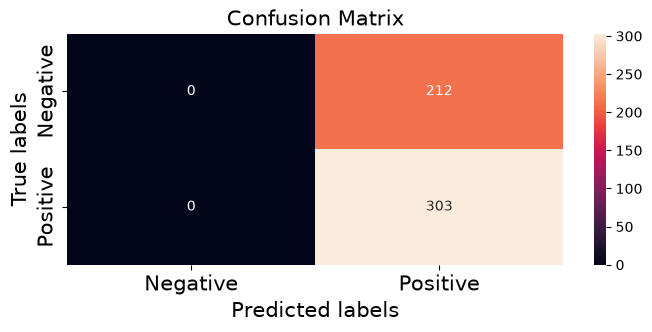

In [27]:
fig, ax= plt.subplots(figsize=(8,3))

sb.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g', ax=ax, )

ax.set_xlabel('Predicted labels',fontsize=15)
ax.set_ylabel('True labels',fontsize=15)
ax.set_title('Confusion Matrix',fontsize=15)
ax.xaxis.set_ticklabels(['Negative', 'Positive'],fontsize=15)
ax.yaxis.set_ticklabels(['Negative', 'Positive'],fontsize=15)